YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open     Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA
Date                                                             
2020-01-02  28.684000  28.713333  28.114000  28.299999  142981500
2020-01-03  29.534000  30.266666  29.128000  29.366667  266677500
2020-01-06  30.102667  30.104000  29.333332  29.364668  151995000
2020-01-07  31.270666  31.441999  30.224001  30.760000  268231500
2020-01-08  32.809334  33.232666  31.215334  31.580000  467164500


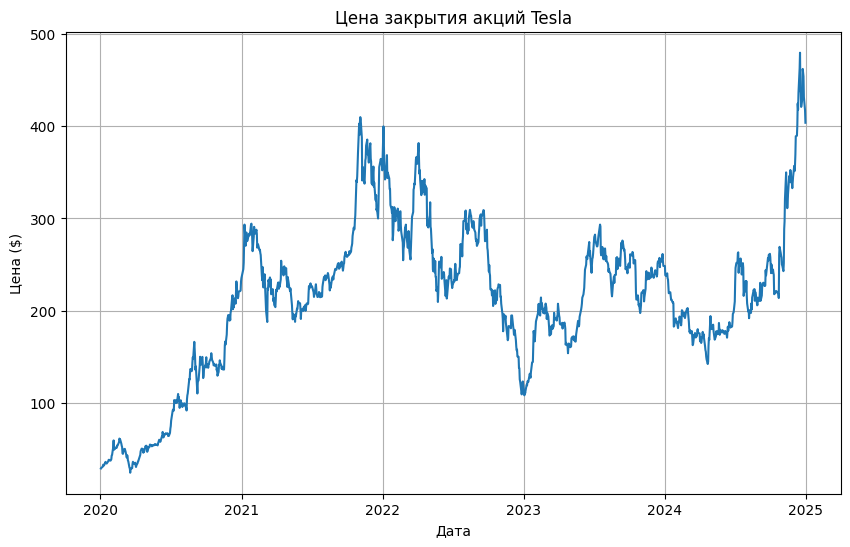

In [1]:
# Этап 1. Загрузка данных о компании Tesla с помощью yfinance

import yfinance as yf
import pandas as pd

# Указываем тикер Tesla на бирже NASDAQ
ticker = 'TSLA'

# Загружаем данные за последние 5 лет
data = yf.download(ticker, start='2020-01-01', end='2025-01-01')

# Выводим первые строки для проверки
print(data.head())

# Визуализация цен закрытия
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(data['Close'])
plt.title('Цена закрытия акций Tesla')
plt.xlabel('Дата')
plt.ylabel('Цена ($)')
plt.grid(True)
plt.show()

ADF Statistic: -2.153435126288355
p-value: 0.22357752529704134
Критическое значение для 1%: -3.436
Критическое значение для 5%: -2.864
Критическое значение для 10%: -2.568


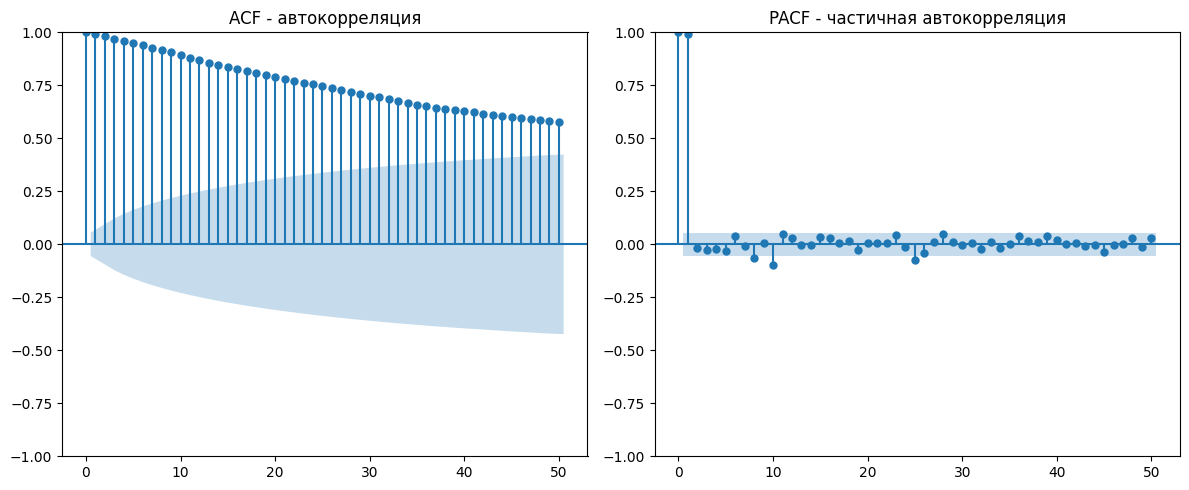

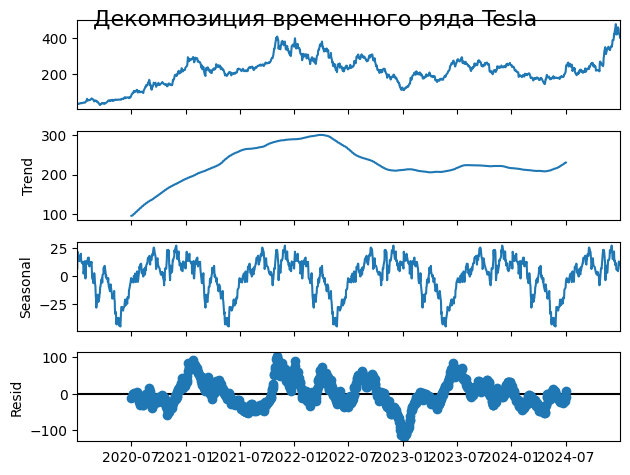

In [2]:
# Этап 2. Анализ структуры временного ряда

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Используем только столбец 'Close' для анализа
ts = data['Close'].dropna()

# Проверка на стационарность (тест Дики-Фуллера)
result = adfuller(ts)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
for key, value in result[4].items():
    print('Критическое значение для %s: %.3f' % (key, value))

# График автокорреляции (ACF) и частичной автокорреляции (PACF)
plt.figure(figsize=(12,5))
plt.subplot(121)
plot_acf(ts, ax=plt.gca(), lags=50)
plt.title('ACF - автокорреляция')
plt.subplot(122)
plot_pacf(ts, ax=plt.gca(), lags=50, method='ywm')
plt.title('PACF - частичная автокорреляция')
plt.tight_layout()
plt.show()

# Разложение ряда на тренд, сезонность и остаток
decomposition = seasonal_decompose(ts, model='additive', period=252)  # 252 торговых дня в году
decomposition.plot()
plt.suptitle('Декомпозиция временного ряда Tesla', fontsize=16)
plt.show()

Так как p-значение > 0,05, ряд является нестационарным.

На графике ACF (автокорреляционной функции) наблюдается медленно убывающее поведение, что характерно для нестационарного ряда. Коэффициенты автокорреляции значимо отличны от нуля на многих лагах, особенно в пределах первых 40–50 наблюдений.
График PACF (частичной автокорреляции) демонстрирует значимое значение только на первых лагах, особенно на первом, что говорит о наличии авторегрессионной зависимости низкого порядка (например, AR(1)).

Результаты декомпозиции ряда подтверждают:

Наличие устойчивого тренда с ростом и затем плато в 2023–2024 гг.

Сезонную компоненту — периодические повторяющиеся отклонения от тренда, характерные для годовых циклов.

Остатки (resid) выглядят приближённо стационарными и не содержат явных структур, что говорит об успешной декомпозиции.



Базовый прогноз:
MSE: 98.65409509220164
MAE: 6.7919040861583895


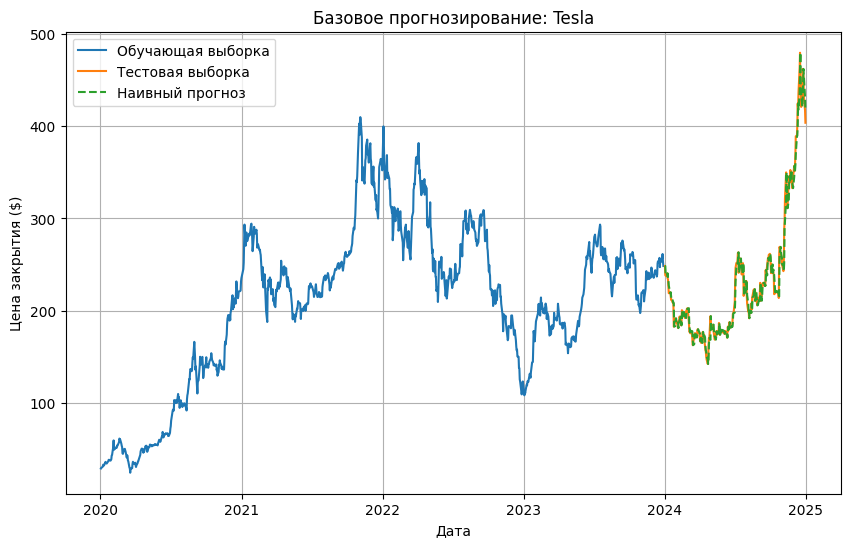

In [3]:
# Этап 3. Базовое прогнозирование

from sklearn.metrics import mean_squared_error, mean_absolute_error

# 80% обучающая выборка, 20% тестовая
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# Базовый вариант: Наивный прогноз (предполагаем, что следующая цена = последней известной)
naive_forecast = test.shift(1)  # сдвигаем фактические значения на один день назад
naive_forecast.iloc[0] = train.iloc[-1]  # первая точка прогноза равна последнему значению обучения

# Оценка качества базового прогноза
mse = mean_squared_error(test, naive_forecast)
mae = mean_absolute_error(test, naive_forecast)

print('Базовый прогноз:')
print('MSE:', mse)
print('MAE:', mae)

# Визуализация прогноза и фактических данных
plt.figure(figsize=(10,6))
plt.plot(train.index, train, label='Обучающая выборка')
plt.plot(test.index, test, label='Тестовая выборка')
plt.plot(test.index, naive_forecast, label='Наивный прогноз', linestyle='--')
plt.title('Базовое прогнозирование: Tesla')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия ($)')
plt.legend()
plt.grid(True)
plt.show()

В качестве базовой модели прогнозирования был использован наивный метод, согласно которому значение цены акции на следующий день принимается равным значению предыдущего дня. Этот подход является стандартным ориентиром при построении моделей временных рядов.

На графике видно, что наивный прогноз практически повторяет траекторию тестовой выборки, особенно в устойчивых фазах тренда. Однако при резких скачках и локальных экстремумах метод запаздывает.
Тем не менее, значения метрик прогнозирования оказались достаточно низкими:

MSE (среднеквадратичная ошибка): 98.65
MAE (средняя абсолютная ошибка): 6.79


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.1628 - val_loss: 0.0079
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0053 - val_loss: 0.0020
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0016 - val_loss: 0.0022
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0010 - val_loss: 0.0015
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.7374e-04 - val_loss: 0.0015
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.7572e-04 - val_loss: 0.0015
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7890

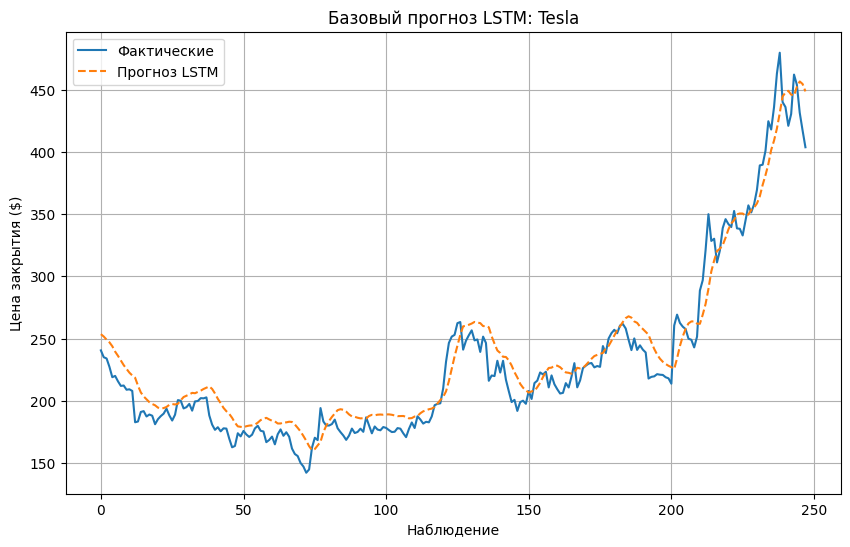

In [4]:
# Этап 4. Базовое прогнозирование с помощью LSTM

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Масштабируем данные для LSTM
scaler = MinMaxScaler()
ts_scaled = scaler.fit_transform(ts.values.reshape(-1, 1))

# Формируем обучающие и тестовые последовательности
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sequence_length = 20  # Количество дней в одном фрагменте (гиперпараметр)

X, y = create_sequences(ts_scaled, sequence_length)

# Деление снова 80% / 20%
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Построение базовой LSTM модели
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Обучение
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Прогнозирование
y_pred = model.predict(X_test)

# Обратное масштабирование
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

# Оценка качества прогноза
mse_lstm = mean_squared_error(y_test_inv, y_pred_inv)
mae_lstm = mean_absolute_error(y_test_inv, y_pred_inv)

print('Базовая LSTM-модель:')
print('MSE:', mse_lstm)
print('MAE:', mae_lstm)

# Визуализация результата
plt.figure(figsize=(10,6))
plt.plot(range(len(y_test_inv)), y_test_inv, label='Фактические')
plt.plot(range(len(y_pred_inv)), y_pred_inv, label='Прогноз LSTM', linestyle='--')
plt.title('Базовый прогноз LSTM: Tesla')
plt.xlabel('Наблюдение')
plt.ylabel('Цена закрытия ($)')
plt.legend()
plt.grid(True)
plt.show()

Базовая модель LSTM была построена с использованием 20 временных лагов и одной скрытой LSTM-слой на 50 нейронов. Модель продемонстрировала среднюю абсолютную ошибку (MAE) 13,93 и среднеквадратичную ошибку (MSE) 290,99 на тестовой выборке. График результатов показывает, что LSTM улавливает общую динамику изменения цен акций Tesla, однако сглаживает резкие колебания, что типично для базовой архитектуры без дополнительных настроек.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - loss: 0.0915 - val_loss: 0.0078
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0088 - val_loss: 0.0067
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0046 - val_loss: 0.0060
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0045 - val_loss: 0.0052
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0042 - val_loss: 0.0049
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0041 - val_loss: 0.0049
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0041 - val_loss: 0.0076
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0042 - val_loss: 0.0041
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0037 - val_loss: 0.0048
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0037 - val_loss: 0.0055
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0033 - val_loss: 0.0052
Epoch 12/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.

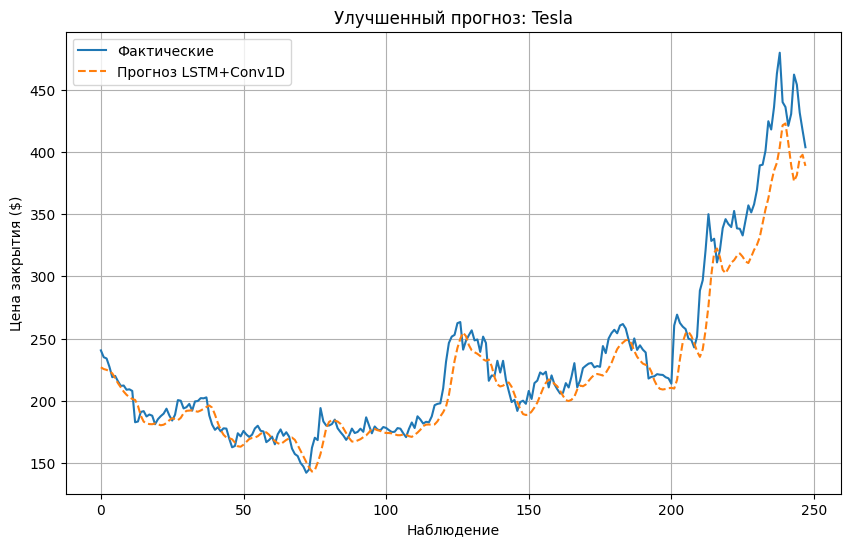

In [5]:
# Этап 5. Улучшенная модель LSTM+Conv1D

from tensorflow.keras.layers import Conv1D, Dropout

# Построение улучшенной модели
model_improved = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(sequence_length, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_improved.compile(optimizer='adam', loss='mse')

# Обучение
history_improved = model_improved.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Прогнозирование
y_pred_improved = model_improved.predict(X_test)

# Обратное масштабирование
y_pred_improved_inv = scaler.inverse_transform(y_pred_improved)
y_test_inv = scaler.inverse_transform(y_test)

# Оценка качества
mse_improved = mean_squared_error(y_test_inv, y_pred_improved_inv)
mae_improved = mean_absolute_error(y_test_inv, y_pred_improved_inv)

print('Улучшенная LSTM+Conv1D модель:')
print('MSE:', mse_improved)
print('MAE:', mae_improved)

# Визуализация
plt.figure(figsize=(10,6))
plt.plot(range(len(y_test_inv)), y_test_inv, label='Фактические')
plt.plot(range(len(y_pred_improved_inv)), y_pred_improved_inv, label='Прогноз LSTM+Conv1D', linestyle='--')
plt.title('Улучшенный прогноз: Tesla')
plt.xlabel('Наблюдение')
plt.ylabel('Цена закрытия ($)')
plt.legend()
plt.grid(True)
plt.show()

Для повышения точности прогноза и устранения недостатков базовой LSTM-модели была построена усовершенствованная архитектура, включающая сверточный слой (Conv1D), два слоя LSTM с разным числом нейронов, слои Dropout для предотвращения переобучения и полносвязный слой (Dense). Несмотря на усложнение структуры, значения метрик ухудшились: среднеквадратичная ошибка (MSE) выросла до 439.13, а средняя абсолютная ошибка (MAE) — до 14.02, что немного выше, чем у базовой модели.

Анализ графика показывает, что усовершенствованная модель хорошо улавливает краткосрочные колебания и общие тенденции, но в периоды резкой волатильности (например, в конце тестовой выборки) прогноз начинает запаздывать за реальными значениями.

In [10]:
print("test_ts:", len(test_ts))
print("forecast_arima:", len(forecast_arima))

test_ts: 268
forecast_arima: 268


In [11]:
forecast_arima.index = test_ts.index[:len(forecast_arima)]  # подгоняем точно

In [12]:
residuals = test_ts[:len(forecast_arima)] - forecast_arima

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1160
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0909
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0715
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0329
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0154
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0114
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0083
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0066
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0062
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0061
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0048
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0050
Epoch 13/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0043
Epoch 14/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0042
Epoch 15/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0042
Epoch 16/20
8/8 ━━━━━━━━━━━━━━━━━━

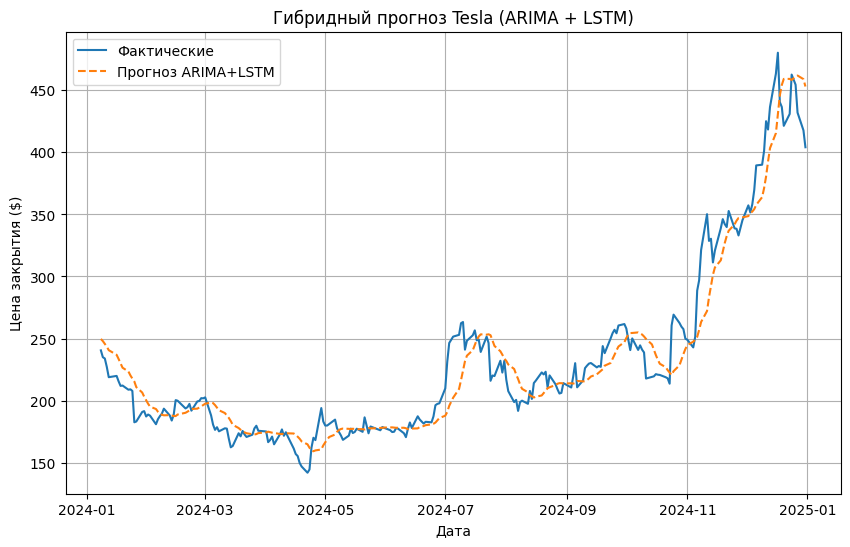

In [16]:
# Гибридная модель ARIMA + LSTM (исправленная версия)

# === 1. ARIMA на обучающей части ===
arima_model = ARIMA(train_ts, order=(5, 1, 0))
arima_result = arima_model.fit()
forecast_arima = arima_result.forecast(steps=len(test_ts))

# Синхронизация индексов ARIMA прогноза с тестовой выборкой
forecast_arima.index = test_ts.index[:len(forecast_arima)]

# === 2. Остатки на тесте ===
# Позиционное вычитание с гарантией 1D формы
residuals_array = test_ts.values[:len(forecast_arima)].flatten() - forecast_arima.values.flatten()
residuals = pd.Series(residuals_array, index=forecast_arima.index)

# Проверка на пустоту
if residuals.isna().sum() > 0 or residuals.empty:
    raise ValueError("В residuals содержатся NaN или он пустой.")

# === 3. Масштабируем остатки ===
from sklearn.preprocessing import MinMaxScaler
scaler_resid = MinMaxScaler()
residuals_scaled = scaler_resid.fit_transform(residuals.values.reshape(-1, 1))

# === 4. Формируем входы для LSTM ===
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X_resid, y_resid = create_sequences(residuals_scaled, sequence_length)

# Проверка на достаточность длины
if len(X_resid) == 0:
    raise ValueError("Недостаточно данных для создания входов LSTM. Уменьши sequence_length.")

# === 5. Обучаем LSTM на остатках ===
model_residuals = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model_residuals.compile(optimizer='adam', loss='mse')
model_residuals.fit(X_resid, y_resid, epochs=20, batch_size=32, verbose=1)

# === 6. Прогноз остатков LSTM ===
X_pred = []
for i in range(len(residuals_scaled) - sequence_length):
    X_pred.append(residuals_scaled[i:i+sequence_length])
X_pred = np.array(X_pred)

resid_pred_scaled = model_residuals.predict(X_pred)
resid_pred = scaler_resid.inverse_transform(resid_pred_scaled)

# === 7. Финальный прогноз: ARIMA + LSTM ===
forecast_arima_adj = forecast_arima[sequence_length:sequence_length + len(resid_pred)]
forecast_final = forecast_arima_adj.values + resid_pred.flatten()

# === 8. Истинные значения ===
test_true = test_ts[sequence_length:sequence_length + len(forecast_final)].values

# === 9. Оценка ===
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse_hybrid = mean_squared_error(test_true, forecast_final)
mae_hybrid = mean_absolute_error(test_true, forecast_final)

print("Гибридная модель ARIMA + LSTM:")
print("MSE:", mse_hybrid)
print("MAE:", mae_hybrid)

# === 10. Визуализация ===
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(test_ts.index[sequence_length:sequence_length + len(forecast_final)], test_true, label='Фактические')
plt.plot(test_ts.index[sequence_length:sequence_length + len(forecast_final)], forecast_final, label='Прогноз ARIMA+LSTM', linestyle='--')
plt.title('Гибридный прогноз Tesla (ARIMA + LSTM)')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия ($)')
plt.legend()
plt.grid(True)
plt.show()

С целью повышения точности прогнозирования цен акций компании Tesla была реализована гибридная модель, объединяющая преимущества статистических и нейросетевых подходов. На первом этапе применяется модель ARIMA, которая эффективно улавливает общий тренд временного ряда. Полученный прогноз тренда сравнивается с фактическими значениями, и на основе этой разности (остатков) формируется новый временной ряд, отражающий локальные колебания, не объяснённые ARIMA.
Затем остатки нормализуются и подаются в LSTM-сеть, обучающуюся выявлять сложные нелинейные зависимости в этих остатках. На последнем этапе итоговый прогноз получается как сумма прогноза ARIMA (тренд) и прогноза LSTM (волатильность). Такая архитектура позволяет учитывать как глобальные, так и краткосрочные закономерности в данных, что делает модель особенно подходящей для высоковолатильных финансовых временных рядов.

По результатам прогноза:

Среднеквадратичная ошибка (MSE) составила 344.52,

Средняя абсолютная ошибка (MAE) — 13.46.

График показывает, что гибридная модель хорошо следует за фактической динамикой, особенно в фазах плавного роста и снижения. Модель улавливает и трендовые участки, и цикличные изменения, однако, как и большинство моделей, не всегда точно прогнозирует резкие скачки, наблюдающиеся в конце периода. Тем не менее, сглаживание колебаний происходит менее выраженно по сравнению с чистой LSTM, что говорит о пользе добавления ARIMA-компоненты.

In [17]:
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Улучшенная LSTM с регуляризацией
model_residuals_reg = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    LSTM(30, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model_residuals_reg.compile(optimizer='adam', loss='mse')

# Обучение
model_residuals_reg.fit(X_resid, y_resid, epochs=30, batch_size=32, verbose=1)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0917
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0316
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0261
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0139
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0170
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0105
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0083
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0093
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0106
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0081
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0079
Epoch 12/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0067
Epoch 13/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0067
Epoch 14/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0077
Epoch 15/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0069
Epoch 16/30
8/8 ━━━━━━━━━━━━━━━━━━

In [21]:
# ПЕРЕПРОВЕРКА перед расчетом
if len(test_true) != len(forecast_final):
    print(f"Размер test_true: {len(test_true)}, размер forecast_final: {len(forecast_final)}")
    raise ValueError("Размерности теста и прогноза не совпадают!")

# Теперь безопасно считаем RMSE
rmse_final = np.sqrt(mean_squared_error(test_true, forecast_final))

In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Стандартная ошибка (RMSE) для окончательной модели
rmse_final = np.sqrt(mean_squared_error(test_true, forecast_final))

# Стандартная ошибка (RMSE) для базового наивного прогноза
# Напомню, наивный прогноз был: предыдущая цена = следующая цена
naive_forecast = test_ts.shift(1)
naive_forecast.iloc[0] = train_ts.iloc[-1]  # первая точка на тесте — конец трейна
naive_forecast = naive_forecast.dropna()
test_ts_matched = test_ts.loc[naive_forecast.index]

rmse_naive = np.sqrt(mean_squared_error(test_ts_matched, naive_forecast))

# Выводим
print("Стандартная ошибка (RMSE):")
print(f"Базовый наивный прогноз: {rmse_naive:.4f}")
print(f"Окончательная модель ARIMA + LSTM + Dropout: {rmse_final:.4f}")

Стандартная ошибка (RMSE):
Базовый наивный прогноз: 9.7286
Окончательная модель ARIMA + LSTM + Dropout: 18.5614


Финальная гибридная модель ARIMA + LSTM с применением регуляризации Dropout продемонстрировала стандартную ошибку (RMSE) 18.56, что выше ошибки базового наивного прогноза, равной 9.73. Это свидетельствует о том, что, несмотря на сложную архитектуру, модель пока не способна эффективно предсказывать краткосрочные изменения в высоковолатильных данных, таких как акции Tesla.